# Actividad 4 — Dataset del SMN (versión corregida)

Región elegida: **Pampeana** (Buenos Aires, Córdoba, Santa Fe, Entre Ríos, La Pampa,
Capital Federal).

En la entrega original hubo dos errores que arrastraron 6 de las 9 respuestas de la
Parte II. Los dos están corregidos acá y marcados con ⚠️ donde corresponde:

1. **El merge perdía el 40 % de las estaciones.** Los dos archivos escriben los nombres
   distinto —`estaciones_smn.txt` sin tildes, `estadisticas.txt` con tildes— así que un
   `inner join` por nombre exacto dejaba afuera 70 de 120 estaciones.
2. **Se promediaba el año antes de analizar.** Las preguntas usan `temp` y `prec_mm`, que
   son columnas de una tabla larga con **una fila por estación y por mes**. Colapsar los
   12 meses a un promedio anual destruye la variación estacional y cambia el desvío
   estándar, los outliers y eta cuadrado.

In [1]:
import re
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
PAMPEANA = ["BUENOS AIRES", "CORDOBA", "SANTA FE", "ENTRE RIOS", "LA PAMPA", "CAPITAL FEDERAL"]

## 1. Leer las estaciones

`read_fwf` sin ayuda infiere mal los anchos de este archivo: trunca los nombres largos de
provincia (`SANTIAGO DEL ESTERO` queda en `SANTIAGO DEL ES`) y junta los grados con los
minutos de latitud. Además el archivo tiene dos rarezas: **hay nombres de estación que
siguen en la línea de abajo** y una fila sin código OACI.

Por eso lo parseo con una expresión regular: nombre y provincia son texto, después vienen
seis números y al final el código.

In [2]:
PATRON = re.compile(
    r"^(.{31})(.*?)\s+(-?\d+)\s+(\d+)\s+(-?\d+)\s+(\d+)\s+(-?\d+)\s+(\d+)(?:\s+(\S+))?\s*$"
)

lineas = open("estaciones_smn.txt", encoding="latin-1").read().splitlines()[2:]

filas = []
for i, linea in enumerate(lineas):
    match = PATRON.match(linea)
    if not match:
        continue  # las lineas sueltas son continuaciones de nombre, se pegan abajo

    nombre, provincia, lat_gr, lat_min, lon_gr, lon_min, altura, nro, oaci = match.groups()
    nombre = nombre.strip()

    # si la linea siguiente no matchea el patron, es la continuacion de este nombre
    siguiente = lineas[i + 1] if i + 1 < len(lineas) else ""
    if siguiente.strip() and not PATRON.match(siguiente):
        nombre += siguiente.strip()

    filas.append({
        "NOMBRE": nombre,
        "PROVINCIA": provincia.strip(),
        "LAT_GR": int(lat_gr),
        "LON_GR": int(lon_gr),
        "ALTURA": float(altura),
        "NRO": nro,
        "OACI": oaci,
    })

estaciones = pd.DataFrame(filas)
print("Estaciones parseadas:", len(estaciones))
estaciones.head()

Estaciones parseadas: 118


,NOMBRE,PROVINCIA,LAT_GR,LON_GR,ALTURA,NRO,OACI
0,BASE BELGRANO II,ANTARTIDA,-77,-34,256.0,89034,SAYB
1,BASE CARLINI (EX JUBANY),ANTARTIDA,-62,-58,11.0,89053,SAYJ
2,BASE ESPERANZA,ANTARTIDA,-63,-56,24.0,88963,SAYE
3,BASE MARAMBIO,ANTARTIDA,-64,-56,198.0,89055,SAWB
4,BASE ORCADAS,ANTARTIDA,-60,-44,12.0,88968,SAYO


Control: las provincias tienen que estar completas, sin truncar.

In [3]:
sorted(estaciones["PROVINCIA"].unique())

['ANTARTIDA',
 'BUENOS AIRES',
 'CAPITAL FEDERAL',
 'CATAMARCA',
 'CHACO',
 'CHUBUT',
 'CORDOBA',
 'CORRIENTES',
 'ENTRE RIOS',
 'FORMOSA',
 'JUJUY',
 'LA PAMPA',
 'LA RIOJA',
 'MENDOZA',
 'MISIONES',
 'NEUQUEN',
 'RIO NEGRO',
 'SALTA',
 'SAN JUAN',
 'SAN LUIS',
 'SANTA CRUZ',
 'SANTA FE',
 'SANTIAGO DEL ESTERO',
 'TIERRA DEL FUEGO',
 'TUCUMAN']

## 2. Leer las estadísticas climatológicas

El archivo trae 5 líneas de encabezado y usa `S/D` para los datos faltantes, así que hay
que convertir los meses a número con `errors="coerce"` para que esos `S/D` se vuelvan
`NaN` en vez de romper la columna.

In [4]:
estadisticas = pd.read_csv("estadisticas.txt", sep="\t", encoding="latin-1", skiprows=5)

for mes in MESES:
    estadisticas[mes] = pd.to_numeric(estadisticas[mes], errors="coerce")

print("Filas:", len(estadisticas), "| Estaciones distintas:", estadisticas["Estación"].nunique())
estadisticas.head()

Filas: 608 | Estaciones distintas: 76


,Estación,Valor Medio de,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
0,LA QUIACA OBS.,Temperatura (°C),12.8,12.5,12.4,10.9,6.9,4.4,4.1,6.7,9.3,11.7,12.8,13.2
1,LA QUIACA OBS.,Temperatura máxima (°C),20.1,19.9,19.9,19.7,17.3,15.6,15.4,17.4,19.2,21.1,21.7,21.3
2,LA QUIACA OBS.,Temperatura mínima (°C),7.4,7.0,6.3,2.8,-3.0,-6.2,-6.8,-4.2,-1.1,2.8,5.2,6.9
3,LA QUIACA OBS.,Humedad relativa (%),65.3,64.1,62.4,48.2,34.6,31.1,30.1,31.7,34.4,45.3,52.3,59.2
4,LA QUIACA OBS.,Velocidad del Viento (km/h),6.9,7.1,6.5,6.4,6.0,4.9,6.6,6.6,8.6,8.7,8.8,8.3


## 3. ⚠️ Error 1 — normalizar los nombres antes de unir

Acá estaba el bug principal. Los mismos lugares aparecen escritos distinto en cada
archivo:

| `estaciones_smn.txt` | `estadisticas.txt` |
|---|---|
| `BAHIA BLANCA AERO` | `BAHÍA BLANCA AERO` |
| `CORDOBA AERO` | `CÓRDOBA AERO` |
| `NEUQUEN AERO` | `NEUQUÉN AERO` |
| `PILAR OBSERVATORIO` | `PILAR OBS.` |

Para Python `"CORDOBA" != "CÓRDOBA"`, así que el `inner join` las descartaba en silencio.

`unicodedata.normalize("NFKD", ...)` separa cada letra de su tilde en dos caracteres, y
después se filtran los caracteres combinantes: así `Ó` queda en `O`.

In [5]:
def normalizar(texto):
    """Deja el nombre comparable: sin tildes, en mayúsculas y con espacios simples."""
    t = unicodedata.normalize("NFKD", str(texto))
    t = "".join(c for c in t if not unicodedata.combining(c))
    t = " ".join(t.upper().split())
    # dos abreviaturas que difieren entre los archivos
    return t.replace(" OBSERVATORIO", " OBS.").replace("VILLA DE MARIA", "VILLA MARIA")


estaciones["KEY"] = estaciones["NOMBRE"].map(normalizar)
estadisticas["KEY"] = estadisticas["Estación"].map(normalizar)

# caso puntual: figura como "BUENOS AIRES OBSERVATORIO" y como "BUENOS AIRES"
estaciones.loc[estaciones["NOMBRE"] == "BUENOS AIRES OBSERVATORIO", "KEY"] = "BUENOS AIRES"

crudo = set(estaciones["NOMBRE"]) & set(estadisticas["Estación"])
normalizado = set(estaciones["KEY"]) & set(estadisticas["KEY"])
print("Coinciden usando el nombre crudo :", len(crudo))
print("Coinciden normalizando           :", len(normalizado))
print("Estaciones recuperadas           :", len(normalizado) - len(crudo))

Coinciden usando el nombre crudo : 50
Coinciden normalizando           : 75
Estaciones recuperadas           : 25


## 4. ⚠️ Error 2 — pasar a formato largo (una fila por estación y mes)

El archivo viene ancho: una fila por estación y variable, con los 12 meses en columnas.
Las preguntas piden `temp` y `prec_mm`, o sea el formato **largo**: una fila por estación
y por mes, con una columna por variable.

`melt` estira los meses a filas y `pivot_table` convierte los valores de
`"Valor Medio de"` en columnas.

In [6]:
largo = estadisticas.melt(
    id_vars=["KEY", "Valor Medio de"],
    value_vars=MESES,
    var_name="mes",
    value_name="valor",
)

tidy = largo.pivot_table(
    index=["KEY", "mes"],
    columns="Valor Medio de",
    values="valor",
    aggfunc="first",
).reset_index()

tidy = tidy.rename(columns={
    "Temperatura (°C)": "temp",
    "Precipitación (mm)": "prec_mm",
    "Humedad relativa (%)": "hum",
    "Nubosidad total (octavos)": "nub",
    "Velocidad del Viento (km/h)": "viento",
})

print("Filas:", len(tidy), "= estaciones x 12 meses")
tidy.head()

Filas: 912 = estaciones x 12 meses


Valor Medio de,KEY,mes,Frecuencia de días con Precipitación superior a 0.1 mm,hum,nub,prec_mm,temp,Temperatura máxima (°C),Temperatura mínima (°C),viento
0,AEROPARQUE AERO,Abr,8.3,74.6,3.4,105.6,18.2,21.7,14.9,14.1
1,AEROPARQUE AERO,Ago,6.1,74.8,3.9,56.3,12.7,16.3,9.6,15.3
2,AEROPARQUE AERO,Dic,8.2,66.6,3.3,105.2,22.9,27.0,19.1,17.4
3,AEROPARQUE AERO,Ene,8.3,67.8,3.1,117.4,24.5,28.4,20.8,17.2
4,AEROPARQUE AERO,Feb,7.9,70.9,3.2,107.7,23.5,27.2,20.0,16.4


## 5. Unir las dos tablas — y controlar que no se pierda nada

**La regla:** después de todo `merge`, comparar cuántas filas había antes y cuántas
quedaron. Un `inner join` borra en silencio; si perdiste filas hay que entender por qué
antes de seguir. En la entrega original esto pasó de 120 a 50 estaciones y no se detectó.

In [7]:
disponibles = tidy["KEY"].nunique()
df = estaciones.merge(tidy, on="KEY", how="inner")

print("Estaciones con estadísticas    :", disponibles)
print("Estaciones tras el merge       :", df["KEY"].nunique())
print("Filas del dataset final        :", len(df))
df.head()

Estaciones con estadísticas    : 76
Estaciones tras el merge       : 75
Filas del dataset final        : 900


,NOMBRE,PROVINCIA,LAT_GR,LON_GR,ALTURA,NRO,OACI,KEY,mes,Frecuencia de días con Precipitación superior a 0.1 mm,hum,nub,prec_mm,temp,Temperatura máxima (°C),Temperatura mínima (°C),viento
0,BASE BELGRANO II,ANTARTIDA,-77,-34,256.0,89034,SAYB,BASE BELGRANO II,Abr,NaN,NaN,4.4,NaN,-16.7,-13.5,-20.7,NaN
1,BASE BELGRANO II,ANTARTIDA,-77,-34,256.0,89034,SAYB,BASE BELGRANO II,Ago,NaN,NaN,4.6,NaN,-20.2,-16.6,-24.4,NaN
2,BASE BELGRANO II,ANTARTIDA,-77,-34,256.0,89034,SAYB,BASE BELGRANO II,Dic,NaN,NaN,5.0,NaN,-3.0,0.4,-6.9,NaN
3,BASE BELGRANO II,ANTARTIDA,-77,-34,256.0,89034,SAYB,BASE BELGRANO II,Ene,NaN,NaN,5.4,NaN,-2.4,0.7,-5.9,NaN
4,BASE BELGRANO II,ANTARTIDA,-77,-34,256.0,89034,SAYB,BASE BELGRANO II,Feb,NaN,NaN,5.0,NaN,-7.0,-3.7,-10.9,NaN


## 6. Filtrar la región Pampeana

In [8]:
pampeana = df[df["PROVINCIA"].isin(PAMPEANA)]

print("Filas:", len(pampeana), "| Estaciones:", pampeana["KEY"].nunique())
pampeana["PROVINCIA"].value_counts()

Filas: 396 | Estaciones: 33


PROVINCIA
BUENOS AIRES       168
CORDOBA             96
SANTA FE            48
ENTRE RIOS          36
CAPITAL FEDERAL     24
LA PAMPA            24
Name: count, dtype: int64

---
# Respuestas

### P1 — ¿Cuántas estaciones meteorológicas hay en la región?

In [9]:
pampeana["KEY"].nunique()   # 33 -> "entre 31 y 40"

33

### P2 — ¿Cuál es la altura media de las estaciones?

Se calcula **por estación**, no sobre las filas estación-mes: si no, cada estación pesaría
12 veces.

In [10]:
por_estacion = pampeana.groupby(["KEY", "PROVINCIA"], as_index=False).agg(
    ALTURA=("ALTURA", "first")
)
por_estacion["ALTURA"].mean()   # 145.2 m -> "entre 101 m y 300 m"

np.float64(145.15151515151516)

### P3 y P4 — Temperatura media y desvío estándar de la región

In [11]:
print("Media :", round(pampeana["temp"].mean(), 2), "°C")   # -> "entre 15.1 y 20 °C"
print("Desvío:", round(pampeana["temp"].std(), 2), "°C")    # -> "entre 5 y 10 °C"

Media : 16.58 °C
Desvío: 5.2 °C


#### Por qué importa el nivel de agregación

Este es el error 2 en números. El mismo dato, medido de dos formas:

In [12]:
anual = pampeana.groupby(["KEY", "PROVINCIA"], as_index=False)[["temp", "prec_mm"]].mean()

print("Desvío a nivel estación-mes    :", round(pampeana["temp"].std(), 2), "°C")
print("Desvío promediando el año antes:", round(anual["temp"].std(), 2), "°C")
print()
print("El primero incluye la diferencia entre invierno y verano.")
print("El segundo solo mide cuánto difieren las estaciones entre sí,")
print("y la región Pampeana es climáticamente muy pareja.")

Desvío a nivel estación-mes    : 5.2 °C
Desvío promediando el año antes: 1.71 °C

El primero incluye la diferencia entre invierno y verano.
El segundo solo mide cuánto difieren las estaciones entre sí,
y la región Pampeana es climáticamente muy pareja.


### P5 — ¿En qué mes se registra la mayor precipitación media?

In [13]:
prec_por_mes = pampeana.groupby("mes")["prec_mm"].mean().reindex(MESES)
print(prec_por_mes.round(1).to_string())
print("\nMáximo:", prec_por_mes.idxmax())   # -> Marzo

mes
Ene    115.6
Feb    108.7
Mar    122.2
Abr     91.3
May     53.1
Jun     32.7
Jul     33.4
Ago     35.0
Sep     53.9
Oct     96.6
Nov    104.7
Dic    113.2

Máximo: Mar


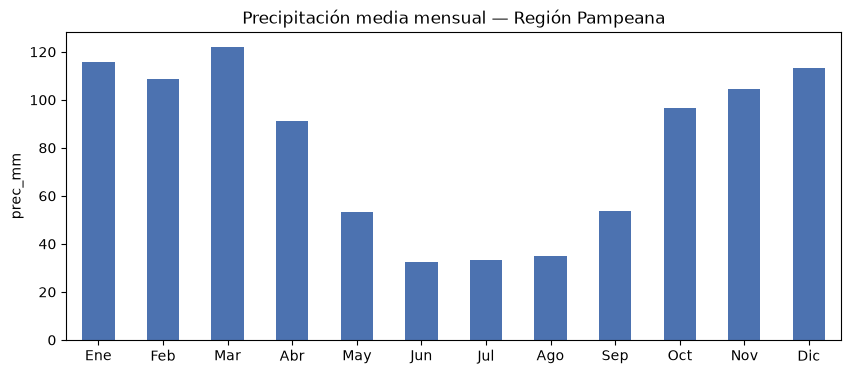

In [14]:
plt.figure(figsize=(10, 4))
prec_por_mes.plot(kind="bar", color="#4C72B0")
plt.title("Precipitación media mensual — Región Pampeana")
plt.ylabel("prec_mm")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()

### P6 — ¿Qué provincia tiene la mayor temperatura media?

In [15]:
pampeana.groupby("PROVINCIA")["temp"].mean().sort_values(ascending=False).round(2)

PROVINCIA
SANTA FE           18.81
ENTRE RIOS         18.33
CAPITAL FEDERAL    17.88
CORDOBA            17.23
LA PAMPA           15.83
BUENOS AIRES       15.13
Name: temp, dtype: float64

En la entrega original esto daba **Entre Ríos**, porque el merge roto había dejado una
sola estación (Concordia, 18.90 °C) representando toda la provincia. Con las 3 estaciones
reales, Entre Ríos baja a 18.33 y **Santa Fe** queda primera.

### P7 — ¿En qué variables aparecen outliers?

In [16]:
def contar_outliers(serie):
    """Regla del IQR de Tukey con k = 1.5."""
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())


print("Outliers en temp   :", contar_outliers(pampeana["temp"]))
print("Outliers en prec_mm:", contar_outliers(pampeana["prec_mm"]))
print("\n-> Ninguna de las dos variables tiene outliers.")

Outliers en temp   : 0
Outliers en prec_mm: 0

-> Ninguna de las dos variables tiene outliers.


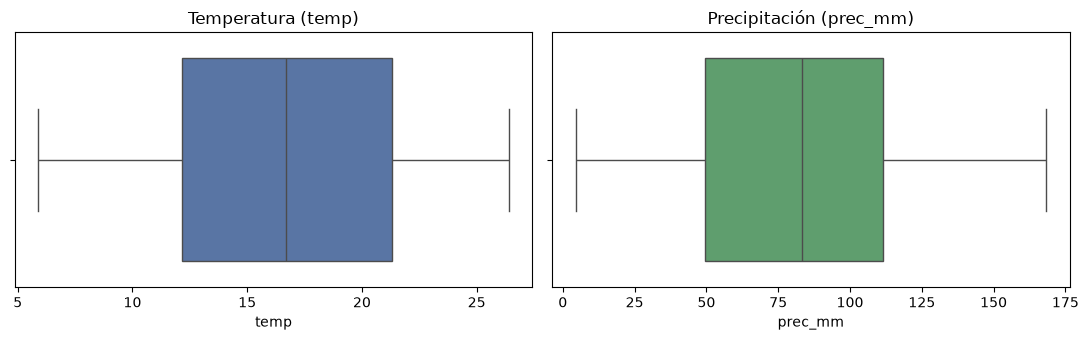

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=pampeana["temp"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Temperatura (temp)")
sns.boxplot(x=pampeana["prec_mm"], ax=axes[1], color="#55A868")
axes[1].set_title("Precipitación (prec_mm)")
plt.tight_layout()
plt.show()

### P8 — Correlación de Spearman entre altura y temperatura

In [18]:
rho = pampeana["ALTURA"].corr(pampeana["temp"], method="spearman")
print("rho =", round(rho, 3))
print("-> Prácticamente cero: no hay relación aparente.")
print("   Tiene sentido: la Pampeana es llana, casi no hay variación de altura.")

rho = -0.035
-> Prácticamente cero: no hay relación aparente.
   Tiene sentido: la Pampeana es llana, casi no hay variación de altura.


### P9 — Eta cuadrado entre provincia y precipitación

Eta cuadrado es la **proporción de la varianza de la variable numérica que explica la
categórica**: `SS_entre / SS_total`. Va de 0 a 1.

In [19]:
def eta_cuadrado(datos, categorica, numerica):
    d = datos.dropna(subset=[numerica])
    media_general = d[numerica].mean()

    ss_entre = sum(
        len(grupo) * (grupo[numerica].mean() - media_general) ** 2
        for _, grupo in d.groupby(categorica)
    )
    ss_total = ((d[numerica] - media_general) ** 2).sum()

    return ss_entre / ss_total


eta = eta_cuadrado(pampeana, "PROVINCIA", "prec_mm")
print("eta² =", round(eta, 4), "-> asociación débil")

eta² = 0.0667 -> asociación débil


#### El mismo estadístico, conclusión opuesta

Acá se ve por qué el nivel de agregación no es un detalle:

In [20]:
print("eta² a nivel estación-mes     :", round(eta_cuadrado(pampeana, "PROVINCIA", "prec_mm"), 4), "-> débil")
print("eta² promediando el año antes :", round(eta_cuadrado(anual, "PROVINCIA", "prec_mm"), 4), "-> fuerte")
print()
print("Al promediar el año se borra la estacionalidad, que es la mayor fuente de")
print("varianza y que la provincia NO explica. Sin ella, la provincia parece")
print("explicar casi todo lo que queda.")

eta² a nivel estación-mes     : 0.0667 -> débil
eta² promediando el año antes : 0.5689 -> fuerte

Al promediar el año se borra la estacionalidad, que es la mayor fuente de
varianza y que la provincia NO explica. Sin ella, la provincia parece
explicar casi todo lo que queda.


---
## Cierre — Caracterización climática de Buenos Aires

In [21]:
bsas = pampeana[pampeana["PROVINCIA"] == "BUENOS AIRES"]

print("Estaciones consideradas:", bsas["KEY"].nunique())
bsas[["temp", "prec_mm", "hum", "nub", "viento"]].mean().round(2)

Estaciones consideradas: 14


temp       15.13
prec_mm    78.71
hum        74.19
nub         3.88
viento     12.34
dtype: float64

En la entrega original estos promedios salían de 9 estaciones en vez de 14, así que los
valores cambian un poco.

También conviene revisar el régimen de lluvias antes de afirmar en qué estación del año
se concentran:

In [22]:
bsas.groupby("mes")["prec_mm"].mean().reindex(MESES).round(1)

mes
Ene    105.2
Feb    101.6
Mar    109.3
Abr     87.1
May     62.1
Jun     40.7
Jul     42.8
Ago     45.9
Sep     61.0
Oct    102.2
Nov     95.4
Dic     91.2
Name: prec_mm, dtype: float64

El máximo es **marzo** (final del verano / principio del otoño) y el mínimo **junio-julio**
(invierno). Es un régimen con lluvias repartidas todo el año pero con mínimo invernal
marcado — más preciso que decir que se concentran en verano.